# Initialization

## Libraries

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1 import host_subplot
import mpl_toolkits.axisartist as AA

## Directories

In [2]:
data_dir = Path("data")
Path.mkdir(data_dir, exist_ok=True)

plot_dir = Path("plots")
Path.mkdir(plot_dir, exist_ok=True)

log_dir = Path("logs")
Path.mkdir(log_dir, exist_ok=True)

## Data reading

In [3]:
data_file = "Dataset_SL.xlsx"

### Define experimental data

In [4]:
# 1. Define the experimental data
experiment_data = pd.read_excel(data_dir / data_file, sheet_name="Datasheet")

In [5]:
# make the other columns as floats
experiment_data = experiment_data.astype(
    {
        "salt_concentration": float,
        "water_to_cement_ratio": float,
        "antisettling_concentration": float,
        "E_d": float,
        "KPI": float,
    }
)

# get optimization round for later use in saving
opt_round = experiment_data["opt_round"].iloc[-1]

In [6]:
experiment_data.dropna(subset=["E_d"], inplace=True)
experiment_data

,opt_round,salt,salt_concentration,water_to_cement_ratio,antisettling_concentration,kernel,acquisition,obj_func,n_rejected_before_accept,E_d,KPI,Notes
0,0,MgSO4,0.50,1.00,0.00,NaN,NaN,NaN,NaN,39.392651,6.764730,NaN
1,0,CaCl2,0.50,1.00,0.00,NaN,NaN,NaN,NaN,91.053468,2.427368,NaN
2,0,SrBr2,0.50,1.00,0.00,NaN,NaN,NaN,NaN,159.169079,32.224874,NaN
3,0,MgCl2,0.50,1.00,0.00,NaN,NaN,NaN,NaN,88.671748,2.715363,NaN
4,0,CuSO4,0.50,1.00,0.00,NaN,NaN,NaN,NaN,9.658742,61.776688,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
77,3,Zn(NO3)2,0.48,1.34,0.00,RBF,EI,KPI,27.0,105.634319,9.707920,NaN
78,3,MgCl2,0.39,1.04,1.21,RBF,PI,KPI,0.0,62.079727,6.429156,NaN
79,3,Mg(NO3)2,0.21,0.91,0.11,RBF,LCB_low,KPI,33.0,40.210829,9.121303,NaN
80,3,KAl(SO4)2,0.73,1.40,0.00,RBF,LCB_med,KPI,34.0,23.236032,8.052443,NaN


# Plots

## Objective function

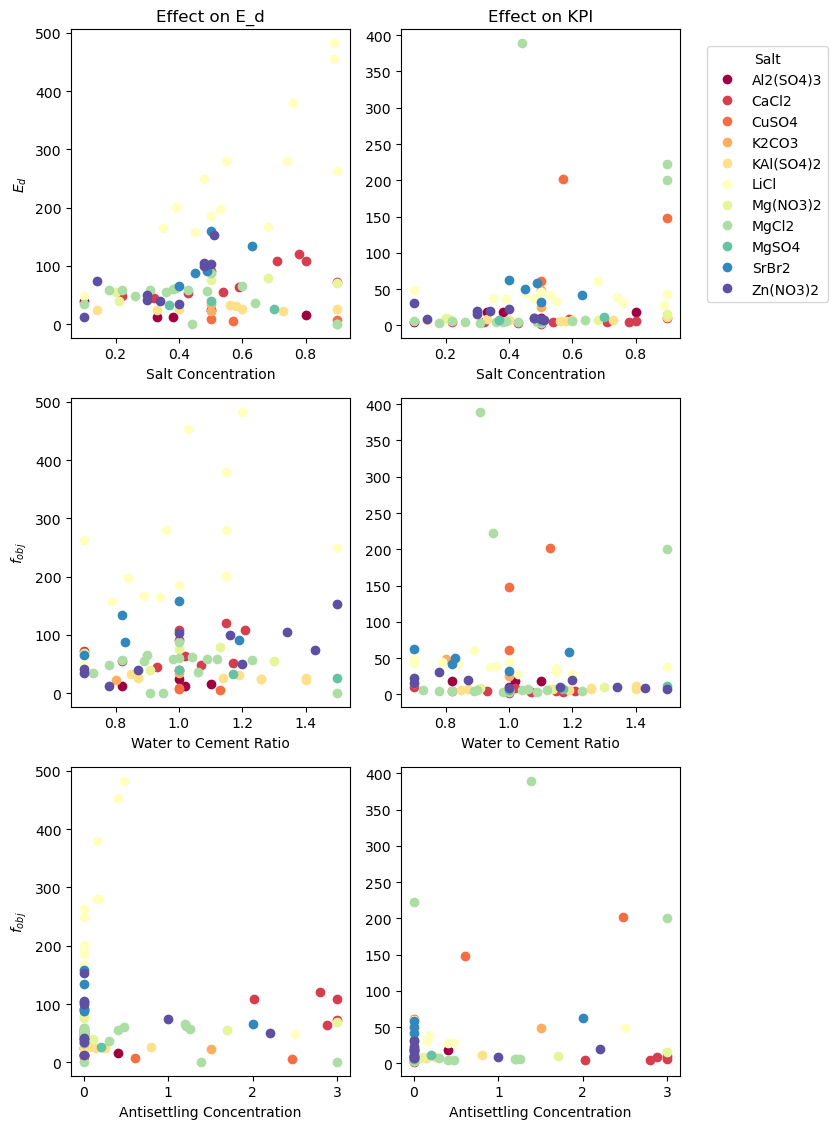

In [22]:
# Define fixed color maps
salt_colors = {
    "Al2(SO4)3": "#9e0142",
    "CaCl2": "#d53e4f",
    "CuSO4": "#f46d43",
    "K2CO3": "#fdae61",
    "KAl(SO4)2": "#fee08b",
    "LiCl": "#ffffbf",
    "Mg(NO3)2": "#e6f598",
    "MgCl2": "#abdda4",
    "MgSO4": "#66c2a5",
    "SrBr2": "#3288bd",
    "Zn(NO3)2": "#5e4fa2",
}

fig, axes = plt.subplots(3, 2, figsize=(7, 12))

# --- First subplot: E_d: salt vs salt_concentration ---
ax = axes[0, 0]
for salt, group in experiment_data.groupby("salt"):
    ax.scatter(
        group["salt_concentration"],
        group["E_d"],
        label=salt,
        alpha=1,
        color=salt_colors.get(salt, "gray"),
    )
ax.set_xlabel("Salt Concentration")
ax.set_ylabel(r"$E_{d}$")
ax.set_title(r"Effect on E_d")

# --- Second subplot: KPI: salt vs salt_concentration ---
ax = axes[0, 1]
for salt, group in experiment_data.groupby("salt"):
    ax.scatter(
        group["salt_concentration"],
        group["KPI"],
        label=salt,
        alpha=1,
        color=salt_colors.get(salt, "gray"),
    )
ax.set_xlabel("Salt Concentration")
ax.set_title(r"Effect on KPI")

# --- Third subplot: E_d: salt vs water_to_cement_ratio ---
ax = axes[1, 0]
for salt, group in experiment_data.groupby("salt"):
    ax.scatter(
        group["water_to_cement_ratio"],
        group["E_d"],
        label=salt,
        alpha=1,
        color=salt_colors.get(salt, "gray"),
    )
ax.set_xlabel("Water to Cement Ratio")
ax.set_ylabel(r"$f_{obj}$")

# --- Fourth subplot: KPI: salt vs water_to_cement_ratio ---
ax = axes[1, 1]
for salt, group in experiment_data.groupby("salt"):
    ax.scatter(
        group["water_to_cement_ratio"],
        group["KPI"],
        label=salt,
        alpha=1,
        color=salt_colors.get(salt, "gray"),
    )
ax.set_xlabel("Water to Cement Ratio")

# --- Fifth subplot: E_d: salt vs antisettling_concentration ---
ax = axes[2, 0]
for salt, group in experiment_data.groupby("salt"):
    ax.scatter(
        group["antisettling_concentration"],
        group["E_d"],
        label=salt,
        alpha=1,
        color=salt_colors.get(salt, "gray"),
    )
ax.set_xlabel("Antisettling Concentration")
ax.set_ylabel(r"$f_{obj}$")

# --- Sixth subplot: KPI: salt antisettling_concentration ---
ax = axes[2, 1]
for salt, group in experiment_data.groupby("salt"):
    ax.scatter(
        group["antisettling_concentration"],
        group["KPI"],
        label=salt,
        alpha=1,
        color=salt_colors.get(salt, "gray"),
    )
ax.set_xlabel("Antisettling Concentration")

# --- Build global legends ---
salt_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=salt_colors[c],
        markersize=8,
        label=c,
    )
    for c in salt_colors
]

# Place the legends outside the plot
fig.legend(
    handles=salt_handles, title="Salt", loc="center right", bbox_to_anchor=(1.2, 0.8)
)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave space on top for legends

plt.savefig("plots/obj_func.pdf")
plt.show()

## Optimization

### Sorted

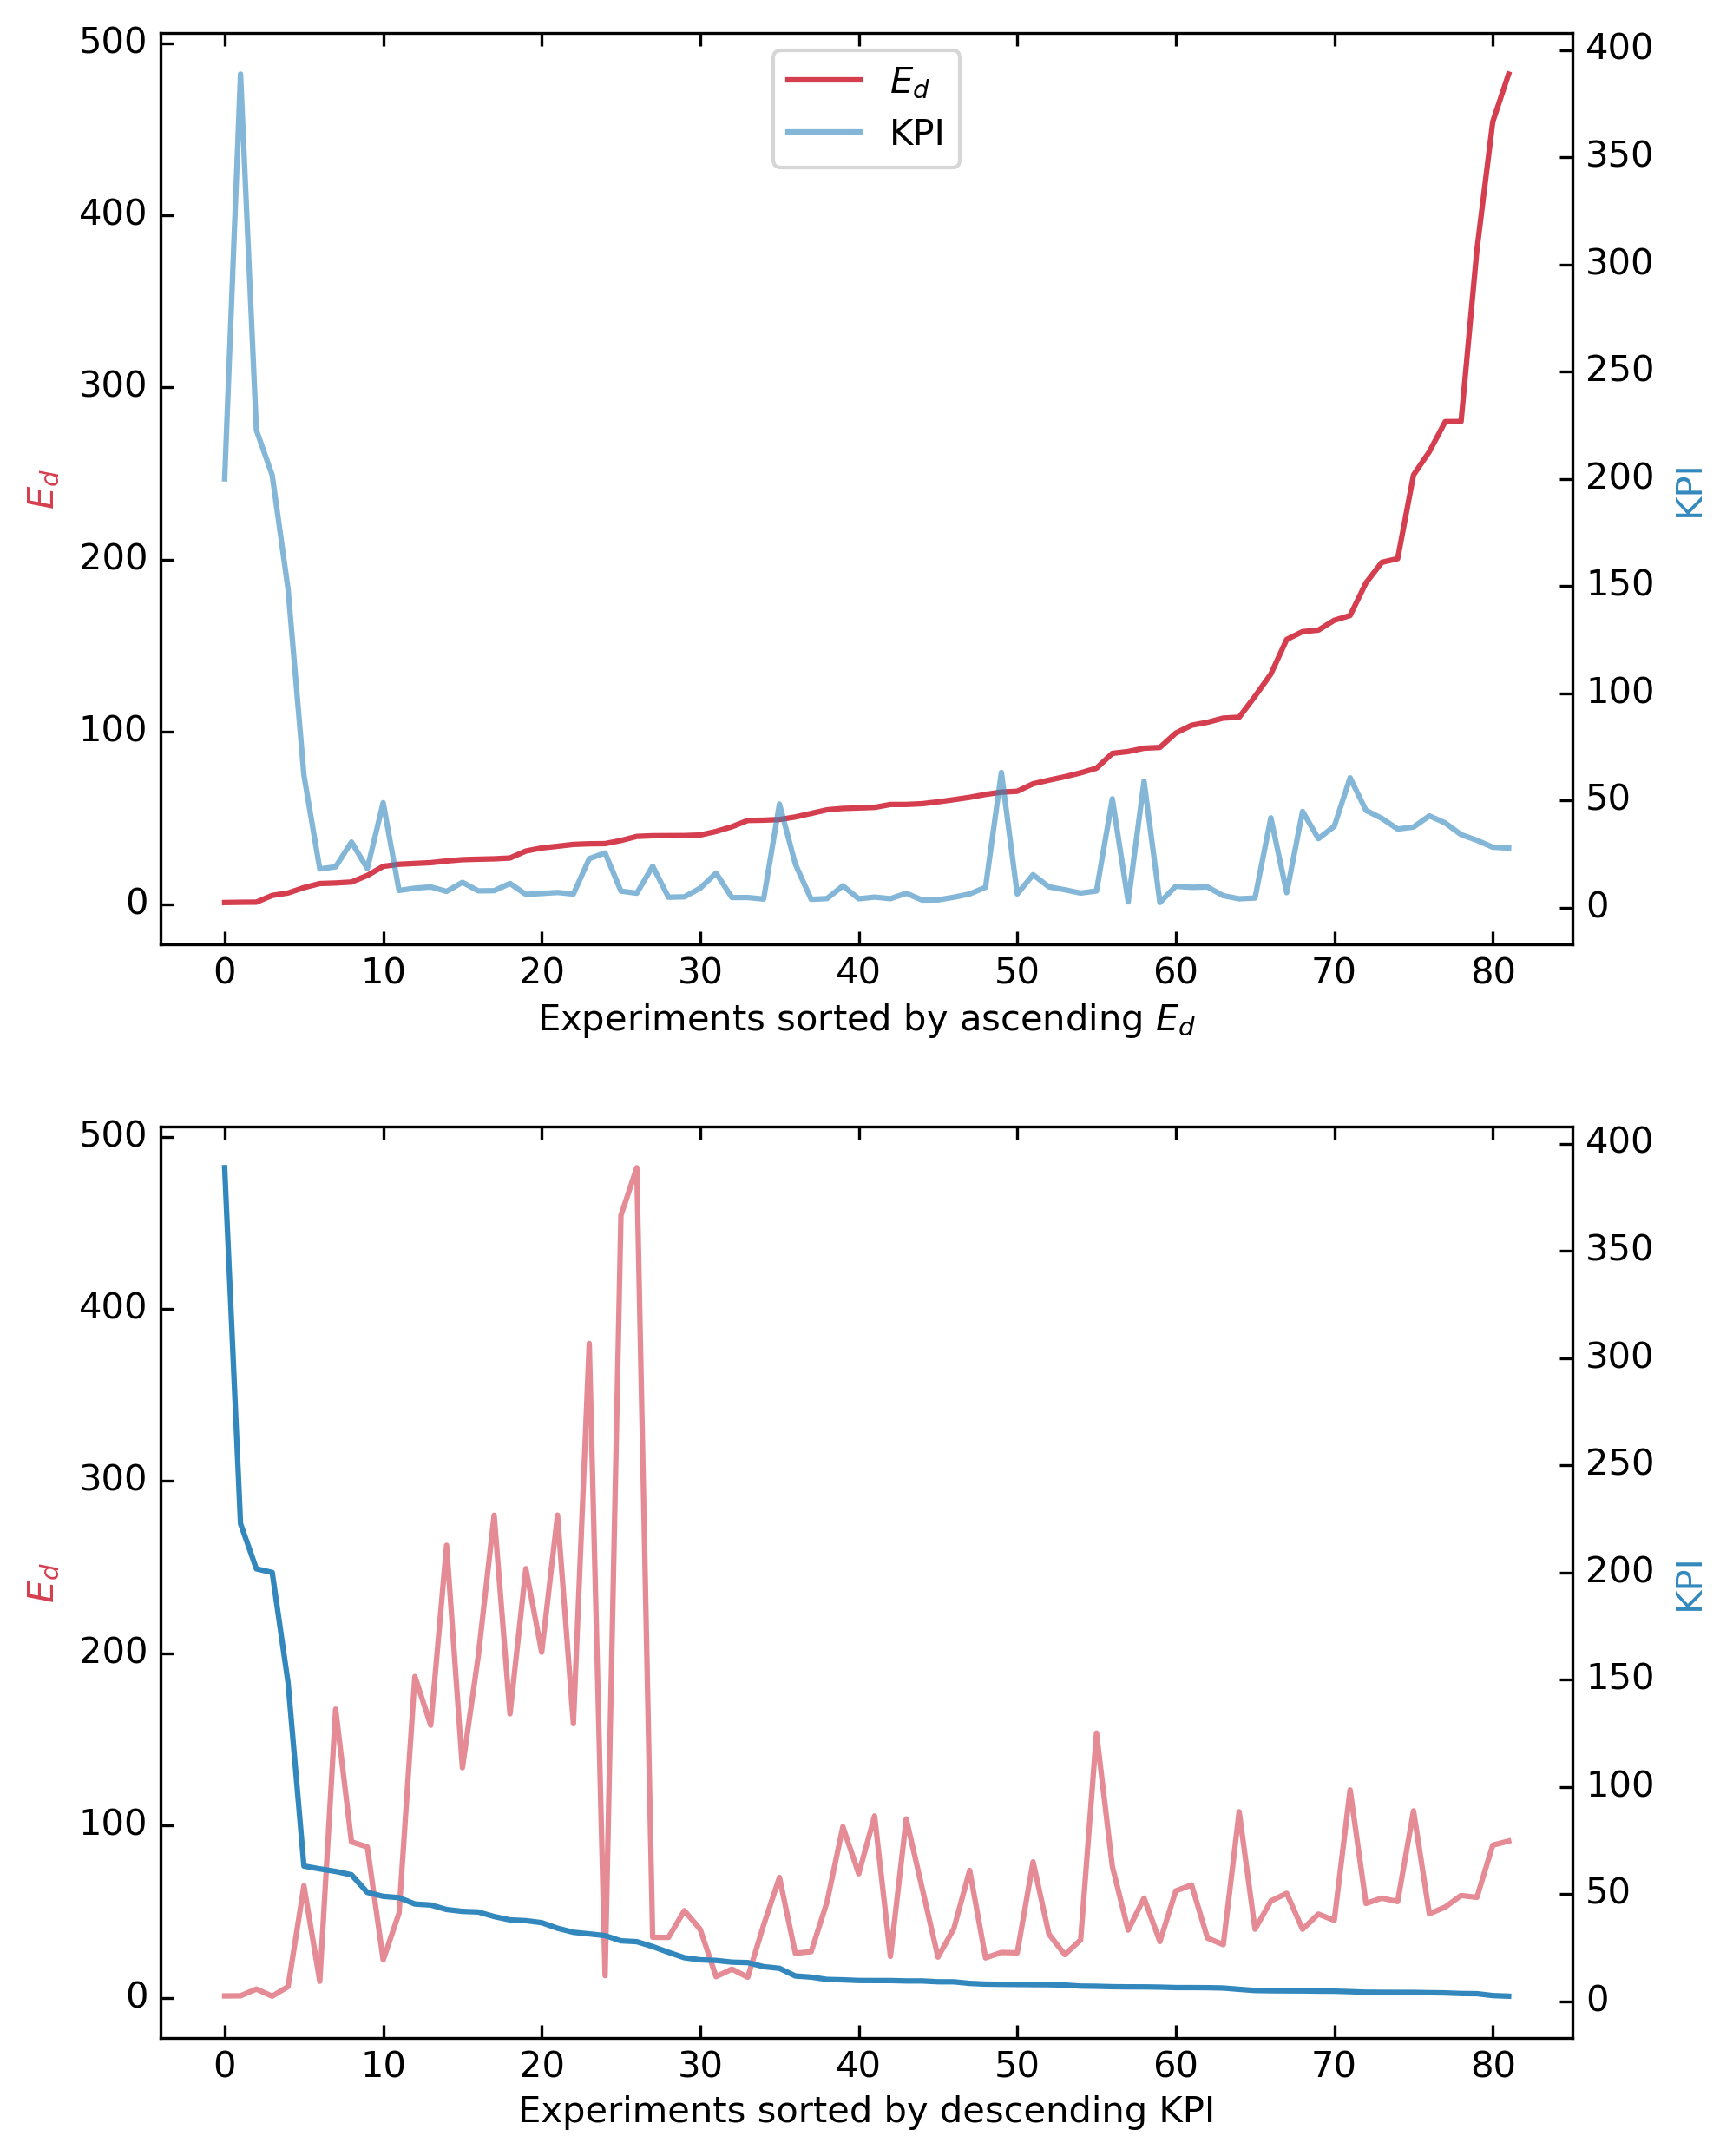

In [9]:
# Create figure
figure = plt.figure(figsize=(7, 10), dpi=300)

# Sort by E_d
df_sorted_Ed = experiment_data.sort_values("E_d").reset_index(drop=True)

# Host axis (left y-axis for E_d)
host = host_subplot(211, axes_class=AA.Axes)

# Create two parasite axis for the right side
par1 = host.twinx()

# Offset the third y-axis (so they don’t overlap)
par1.axis["right"].toggle(all=True)  # turn on ticks and label for KPI axis

# Plot data
(p1,) = host.plot(
    df_sorted_Ed.index, df_sorted_Ed["E_d"], color="#d53e4f", label=r"$E_d$", zorder=2
)
(p2,) = par1.plot(
    df_sorted_Ed.index, df_sorted_Ed["KPI"], color="#3288bd", label="KPI", alpha=0.6
)

# Axis labels
host.set_xlabel(r"Experiments sorted by ascending $E_d$")
host.set_ylabel(r"$E_d$")
par1.set_ylabel("KPI")

# Colors match the plots
host.axis["left"].label.set_color(p1.get_color())
par1.axis["right"].label.set_color(p2.get_color())

# Legend
lines = [p1, p2]
host.legend(lines, [line.get_label() for line in lines], loc="best")


# Sord by KPI
df_sorted_KPI = experiment_data.sort_values("KPI", ascending=False).reset_index(
    drop=True
)

# Host axis (left y-axis for E_d)
host2 = host_subplot(212, axes_class=AA.Axes)

# Create two parasite axes for the right side
par1 = host2.twinx()

# Offset the third y-axis (so they don’t overlap)
par1.axis["right"].toggle(all=True)  # turn on ticks and label for KPI axis

# Plot data
(p1,) = host2.plot(
    df_sorted_KPI.index,
    df_sorted_KPI["E_d"],
    color="#d53e4f",
    label=r"$E_d$",
    alpha=0.6,
)
(p2,) = par1.plot(
    df_sorted_KPI.index, df_sorted_KPI["KPI"], color="#3288bd", label="KPI", zorder=2
)

# Axis labels
host2.set_xlabel(r"Experiments sorted by descending KPI")
host2.set_ylabel(r"$E_d$")
par1.set_ylabel("KPI")

# Colors match the plots
host2.axis["left"].label.set_color(p1.get_color())
par1.axis["right"].label.set_color(p2.get_color())


plt.savefig("plots/sorted.pdf", bbox_inches="tight")
plt.show()

### Chronological

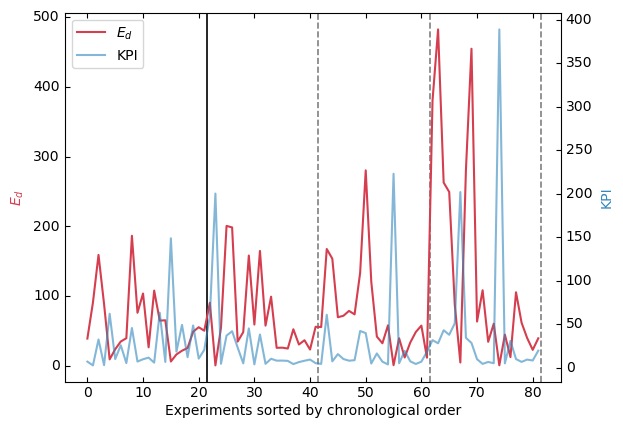

In [41]:
df_unsorted = experiment_data

# Host axis (left y-axis for E_d)
host = host_subplot(111, axes_class=AA.Axes)

# Create parasite axis for the right side
par1 = host.twinx()

# Offset the third y-axis (so they don’t overlap)
par1.axis["right"].toggle(all=True)  # turn on ticks and label for KPI axis

# Plot data
(p1,) = host.plot(
    df_unsorted.index, df_unsorted["E_d"], color="#d53e4f", label=r"$E_d$", zorder=2
)
(p2,) = par1.plot(
    df_unsorted.index, df_unsorted["KPI"], color="#3288bd", label="KPI", alpha=0.6
)

# vertical lines on the shared x-axis (host)
host.axvline(
    x=21.5, color="black", linestyle="-", linewidth=1.2, zorder=0
)  # solid black
for xpos in [41.5, 61.5, 81.5]:
    host.axvline(
        x=xpos, color="gray", linestyle="--", linewidth=1.2, zorder=0
    )  # dashed gray

# Axis labels
host.set_xlabel("Experiments sorted by chronological order")
host.set_ylabel(r"$E_d$")
par1.set_ylabel("KPI")

# Colors match the plots
host.axis["left"].label.set_color(p1.get_color())
par1.axis["right"].label.set_color(p2.get_color())

# Legend
lines = [p1, p2]
host.legend(lines, [line.get_label() for line in lines], loc="best")

plt.savefig("plots/chronological.pdf", bbox_inches="tight")
plt.show()